# Environmental Compliance Risk Prediction

**Machine Learning Classification Project**

**Author:** Makarena Ampuero  
**Course:** Data Science  
**Version:** v2.0.0  
**Date:** June 2026  

---

<p align="center">
  <img src="images/meme4.gif" width="400">
</p>

---

**Project Objective**

The objective of this project is to develop a supervised Machine Learning model capable of predicting environmental non-compliance risk.

This stage includes data preprocessing, automated transformation pipelines, model benchmarking, hyperparameter optimization, final evaluation, and interpretation of business insights.

**Selected problem:**  

Prediction of environmental non-compliance risk.

**Problem type:**  

Supervised Classification

**Target variable:**  

`non_compliance_risk`

---


# Business Context and Problem Definition

# Business Context

Environmental projects require continuous monitoring to ensure compliance with regulatory commitments.

Organizations often manage multiple environmental obligations simultaneously, making it challenging to identify which projects require priority attention.

A data-driven approach can support environmental teams by detecting compliance risk patterns and improving monitoring prioritization.

The objective of this project is to develop a Machine Learning classification model capable of predicting environmental non-compliance risk levels using project characteristics, compliance history, and operational indicators.

The model aims to support preventive environmental management and improve decision-making processes.

# Target Variable

The prediction target is:

**non_compliance_risk**

The model classifies projects into three environmental risk categories:

- **Low Risk:** projects with adequate compliance conditions and lower monitoring priority.
- **Medium Risk:** projects requiring standard monitoring and follow-up actions.
- **High Risk:** projects requiring priority attention due to increased non-compliance risk.

This represents a supervised multiclass classification problem.

# 1. Environment Setup & Libraries

In [142]:
# Package installation

%pip install lazypredict
%pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [143]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    label_binarize
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

# Lazy Predict
from lazypredict.Supervised import LazyClassifier


# Machine Learning Models
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    BaggingClassifier
)

from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.linear_model import SGDClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# Hyperparameter optimization
import optuna

# Save model
import joblib

In [144]:
# Visualization style

sns.set_theme(
    style="whitegrid",
    context="notebook"
)


plt.rcParams.update(
    {
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "figure.figsize": (10, 6)
    }
)

# 2. Data Loading and Preparation


## Load Dataset

In [145]:
environmental_data = pd.read_csv("../selected_dataset/compliance_clean_dataset.csv")

# Rename columns to English for consistency

environmental_data = (
    environmental_data
    .rename(
        columns={
            "empresa": "company",
            "tipo_proyecto": "project_type",
            "region": "region",
            "numero_rca": "rca_number",
            "año_rca": "rca_year",
            "categoria_compromiso": "commitment_category",
            "frecuencia_reporte": "report_frequency",
            "responsable_area": "responsible_area",
            "dias_restantes": "remaining_days",
            "historial_incumplimientos": "non_compliance_history",
            "cantidad_documentos": "document_count",
            "presupuesto_asociado_usd": "associated_budget_usd",
            "criticidad": "criticality",
            "cumplimiento_porcentaje": "compliance_percentage",
            "estado_avance": "progress_status",
            "riesgo_incumplimiento": "non_compliance_risk"
        }
    )
)

environmental_data.head()

,company,project_type,region,rca_number,rca_year,commitment_category,report_frequency,responsible_area,remaining_days,non_compliance_history,document_count,associated_budget_usd,criticality,compliance_percentage,progress_status,non_compliance_risk
0,Colbun,Parque Eolico,Los Lagos,RCA-2308,2019,Reforestacion,Trimestral,Permisos,120,2,21.0,95808.0,Alta,77,En Proceso,Medio
1,Engie,Subestacion,Metropolitana,RCA-3986,2012,Ruido,Semestral,Operacion,285,1,22.0,40997.0,Baja,90,Completado,Bajo
2,Enel,Subestacion,Los Lagos,RCA-1386,2020,Flora y Fauna,Semestral,Medio Ambiente,353,3,17.0,88716.0,Alta,79,En Proceso,Medio
3,Engie,Linea de Transmision,Antofagasta,RCA-7131,2012,Reforestacion,Semestral,Territorio,236,1,5.0,115304.0,Baja,94,Completado,Bajo
4,Engie,Linea de Transmision,Biobio,RCA-4258,2021,Calidad de Aguas,Mensual,Construccion,115,2,6.0,69180.0,Media,66,En Proceso,Bajo


## Initial Verification

In [146]:
environmental_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company                 3000 non-null   str    
 1   project_type            3000 non-null   str    
 2   region                  3000 non-null   str    
 3   rca_number              3000 non-null   str    
 4   rca_year                3000 non-null   int64  
 5   commitment_category     3000 non-null   str    
 6   report_frequency        3000 non-null   str    
 7   responsible_area        3000 non-null   str    
 8   remaining_days          3000 non-null   int64  
 9   non_compliance_history  3000 non-null   int64  
 10  document_count          3000 non-null   float64
 11  associated_budget_usd   3000 non-null   float64
 12  criticality             3000 non-null   str    
 13  compliance_percentage   3000 non-null   int64  
 14  progress_status         3000 non-null   str    
 15

In [147]:
environmental_data.shape

(3000, 16)

## Feature and Target Separation

The dataset was separated into predictor variables (X) and the target variable (y).

The target variable is:

**non_compliance_risk**

This represents a multiclass classification problem.

In [148]:
X = environmental_data.drop(
    columns=[
        "non_compliance_risk"
    ]
)


y = environmental_data[
    "non_compliance_risk"
]

## Train Test Split

In [149]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

A stratified split was applied to preserve the original proportion of risk categories in both training and testing datasets.

# 3. Preprocessing Pipeline

## Column Identification

In [150]:
# Identify numerical features

numeric_features = (
    X
    .select_dtypes(
        include=[
            "int64",
            "float64"
        ]
    )
    .columns
)


# Identify categorical features

categorical_features = (
    X
    .select_dtypes(
        include=[
            "object",
            "string"
        ]
    )
    .columns
)


numeric_features, categorical_features

(Index(['rca_year', 'remaining_days', 'non_compliance_history',
        'document_count', 'associated_budget_usd', 'compliance_percentage'],
       dtype='str'),
 Index(['company', 'project_type', 'region', 'rca_number',
        'commitment_category', 'report_frequency', 'responsible_area',
        'criticality', 'progress_status'],
       dtype='str'))

## ColumnTransformer

In [151]:
numeric_transformer = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),

        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

## Pipeline Configuration

A Machine Learning pipeline strategy was implemented to combine preprocessing and model training into a single workflow.

The pipeline includes:

1. Data preprocessing:
   - Numerical feature scaling using StandardScaler.
   - Categorical feature encoding using OneHotEncoder.

2. Classification model:
   - The classifier step will be replaced by each candidate Machine Learning algorithm during model comparison.

Using pipelines prevents data leakage because preprocessing transformations are fitted only on the training data and then applied to unseen data.

# 4. Initial Model Benchmark - Lazy Predict

Before selecting the final Machine Learning algorithms, an initial benchmark was performed using Lazy Predict.

Lazy Predict allows a quick comparison of multiple classification models using the same dataset, helping identify the most promising algorithms for further evaluation.

In [152]:
# Initialize LazyClassifier

lazy_classifier = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None
)


# Train and evaluate multiple classification models

lazy_models, lazy_predictions = (
    lazy_classifier.fit(
        X_train,
        X_test,
        y_train,
        y_test
    )
)


# Display results

lazy_models.head(
    10
)

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
BaggingClassifier,0.996667,0.984848,0.999977,0.996635,0.996693,0.996667,0.135484
DecisionTreeClassifier,0.996667,0.984848,0.997143,0.996635,0.996693,0.996667,0.065475
RandomForestClassifier,0.986667,0.970606,0.999603,0.986604,0.986597,0.986667,0.280951
ExtraTreesClassifier,0.971667,0.958606,0.999284,0.971492,0.972114,0.971667,0.299153
PassiveAggressiveClassifier,0.955000,0.958002,NaN,0.956104,0.962079,0.955000,0.093522
LinearSVC,0.961667,0.956848,NaN,0.962209,0.965525,0.961667,0.068444
CalibratedClassifierCV,0.956667,0.952848,0.978800,0.957052,0.960803,0.956667,0.170064
RidgeClassifier,0.955000,0.951515,NaN,0.955496,0.959750,0.955000,0.054196
RidgeClassifierCV,0.955000,0.951515,NaN,0.955496,0.959750,0.955000,0.058310


The Lazy Predict benchmark evaluated multiple classification algorithms and ranked them according to their predictive performance.

The results showed that tree-based models achieved the strongest performance, with Bagging Classifier, Decision Tree Classifier, Random Forest Classifier, and Extra Trees Classifier among the top-performing algorithms.

These results were used as a reference for selecting candidate models for a more detailed evaluation using the complete preprocessing pipeline.

## Candidate Model Selection

Based on the Lazy Predict benchmark results, the five best-performing models were selected for detailed evaluation:

- Bagging Classifier
- Decision Tree Classifier
- Random Forest Classifier
- Extra Trees Classifier
- Passive Aggressive Classifier

These algorithms represent different classification approaches, including ensemble methods, individual decision trees, and linear models.

Each selected model will be evaluated using the same preprocessing pipeline and performance metrics to ensure a fair comparison.

In [153]:
lazy_classifier = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None
)


lazy_models, lazy_predictions = (
    lazy_classifier.fit(
        X_train,
        X_test,
        y_train,
        y_test
    )
)


lazy_models.head(10)

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
BaggingClassifier,0.996667,0.984848,0.999977,0.996635,0.996693,0.996667,0.104612
DecisionTreeClassifier,0.996667,0.984848,0.997143,0.996635,0.996693,0.996667,0.057966
RandomForestClassifier,0.986667,0.970606,0.999603,0.986604,0.986597,0.986667,0.285672
ExtraTreesClassifier,0.971667,0.958606,0.999284,0.971492,0.972114,0.971667,0.255789
PassiveAggressiveClassifier,0.955000,0.958002,NaN,0.956104,0.962079,0.955000,0.097615
LinearSVC,0.961667,0.956848,NaN,0.962209,0.965525,0.961667,0.073034
CalibratedClassifierCV,0.956667,0.952848,0.978800,0.957052,0.960803,0.956667,0.144040
RidgeClassifier,0.955000,0.951515,NaN,0.955496,0.959750,0.955000,0.055680
RidgeClassifierCV,0.955000,0.951515,NaN,0.955496,0.959750,0.955000,0.057992


In [154]:

# Define candidate models
# PassiveAggressiveClassifier was replaced by SGDClassifier
# using equivalent parameters because the original implementation
# is deprecated in newer sklearn versions.

models = {
    
    "Bagging Classifier": BaggingClassifier(
        random_state=42
    ),
    
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    
    "Random Forest": RandomForestClassifier(
        random_state=42
    ),
    
    
    "Extra Trees": ExtraTreesClassifier(
        random_state=42
    ),
    
    
    "Passive Aggressive": SGDClassifier(
        loss="hinge",
        penalty=None,
        learning_rate="pa1",
        eta0=1.0,
        random_state=42
    )
}

Lazy Predict was used as an initial benchmark to compare multiple classification algorithms.

Based on the results, the five strongest models were selected for detailed evaluation.

# 5. Model Training and Comparison

Métricas:

- Accuracy
- Precision
- Recall
- F1
- ROC-AUC

F1-Score was selected as the main evaluation metric because environmental risk prediction requires balancing Precision and Recall.

Missing High Risk projects could have operational and regulatory consequences, therefore the model must correctly identify critical cases while avoiding unnecessary alerts.

## Model Training

In [155]:
# Train and compare selected models

results = []


for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),

            (
                "classifier",
                model
            )
        ]
    )


    pipeline.fit(
        X_train,
        y_train
    )


    predictions = pipeline.predict(
        X_test
    )


    results.append(
        {
            "Model": model_name,

            "Accuracy": accuracy_score(
                y_test,
                predictions
            ),

            "Precision": precision_score(
                y_test,
                predictions,
                average="weighted"
            ),

            "Recall": recall_score(
                y_test,
                predictions,
                average="weighted"
            ),

            "F1 Score": f1_score(
                y_test,
                predictions,
                average="weighted"
            )
        }
    )

## Performance Metrics

In [156]:
model_results = (
    pd.DataFrame(results)
    .sort_values(
        by="F1 Score",
        ascending=False
    )
)

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Bagging Classifier,0.996667,0.996693,0.996667,0.996635
1,Decision Tree,0.996667,0.996693,0.996667,0.996635
2,Random Forest,0.973333,0.974126,0.973333,0.973306
3,Extra Trees,0.963333,0.965429,0.963333,0.963373
4,Passive Aggressive,0.960000,0.963941,0.960000,0.960491


The candidate models achieved strong classification results.

Bagging Classifier and Decision Tree Classifier obtained the highest F1-Scores, showing the best balance between Precision and Recall.

Although ensemble models can provide strong predictive performance, interpretability is an important requirement for environmental compliance analysis.

## Model Comparison Visualization

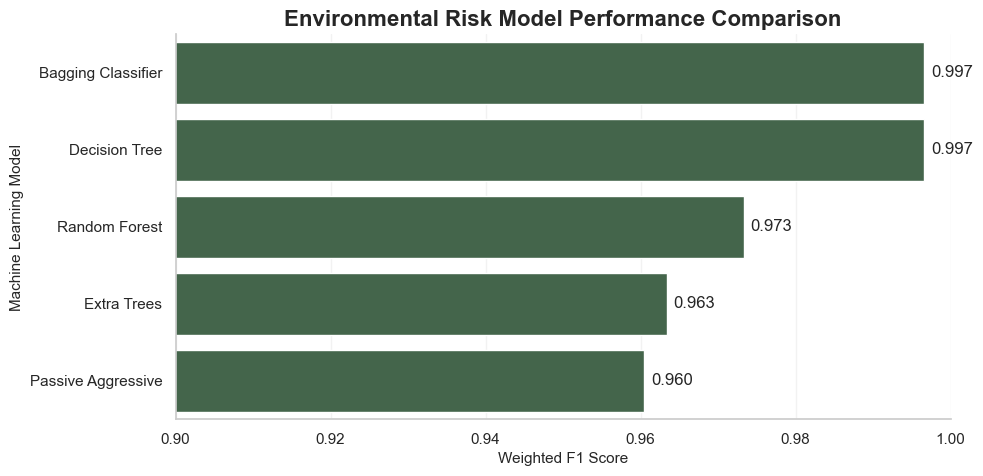

In [157]:
# Model performance visualization

plt.figure(
    figsize=(10,5)
)


ax = sns.barplot(
    data=model_results,
    x="F1 Score",
    y="Model",
    color="#3E6B48"
)


plt.title(
    "Environmental Risk Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel(
    "Weighted F1 Score"
)


plt.ylabel(
    "Machine Learning Model"
)


plt.xlim(
    0.90,
    1.00
)


# Add metric values

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=5
    )


plt.grid(
    axis="x",
    alpha=0.25
)


sns.despine()


plt.show()

**Interpretation**

Tree-based models achieved the strongest classification performance.

Decision Tree was selected because it provided an optimal balance between predictive accuracy and interpretability, which is important for transparent environmental compliance decisions.

## Final Model Selection

Decision Tree Classifier was selected for hyperparameter optimization.

Although Bagging Classifier achieved the same F1-Score, Decision Tree provides:

- Higher interpretability.
- Lower model complexity.
- Easier analysis through feature importance.

In environmental compliance management, understanding why a project is classified as high risk is essential for transparent decision-making.

Therefore, Decision Tree Classifier was selected as the final candidate model.

# 6. Hyperparameter Optimization

After selecting the Decision Tree Classifier as the final candidate model, hyperparameter optimization was performed to improve model performance and generalization.

Three optimization strategies were implemented:

- GridSearchCV: exhaustive search across predefined parameter combinations.
- RandomizedSearchCV: random exploration of the hyperparameter space.
- Optuna: advanced optimization using an efficient search strategy.

The optimization objective was to maximize the weighted F1-Score.

## GridSearchCV

In [158]:
# Decision Tree pipeline

dt_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [159]:
# Define GridSearchCV parameters

param_grid = {
    
    "classifier__criterion": [
        "gini",
        "entropy"
    ],

    "classifier__max_depth": [
        3,
        5,
        10,
        15,
        None
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        4
    ]
}

In [160]:
# Apply GridSearchCV

grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)


grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... ver

In [161]:
print(
    "Best parameters:",
    grid_search.best_params_
)


print(
    "Best score:",
    grid_search.best_score_
)

Best parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best score: 0.9983539986337842


**Results**

The best configuration obtained was:

- Criterion: gini
- Maximum depth: 5
- Minimum samples per leaf: 1
- Minimum samples required to split: 2

The optimized model achieved a cross-validation F1-Score of 0.9983.

## RandomizedSearchCV

In [162]:
# Define RandomizedSearchCV parameters

param_random = {

    "classifier__criterion": [
        "gini",
        "entropy"
    ],

    "classifier__max_depth": [
        3,
        5,
        10,
        15,
        None
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        4,
        8
    ]
}

In [163]:
random_search = RandomizedSearchCV(
    estimator=dt_pipeline,
    param_distributions=param_random,
    n_iter=20,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1
)


random_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directl

In [164]:
print(
    "Best parameters:",
    random_search.best_params_
)


print(
    "Best score:",
    random_search.best_score_
)

Best parameters: {'classifier__min_samples_split': 20, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 15, 'classifier__criterion': 'gini'}
Best score: 0.9983539986337842


**Results**

The best configuration obtained was:

- Criterion: gini
- Maximum depth: 15
- Minimum samples per leaf: 2
- Minimum samples required to split: 20

The optimized model achieved a cross-validation F1-Score of 0.9983.

## Optuna

In [165]:
# Objective function

def objective(trial):

    max_depth = trial.suggest_int(
        "max_depth",
        2,
        20
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split",
        2,
        20
    )

    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf",
        1,
        10
    )

    criterion = trial.suggest_categorical(
        "criterion",
        [
            "gini",
            "entropy"
        ]
    )


    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),

            (
                "classifier",
                DecisionTreeClassifier(
                    criterion=criterion,
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    random_state=42
                )
            )
        ]
    )


    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1_weighted"
    )


    return score.mean()

In [166]:
study = optuna.create_study(
    direction="maximize"
)


study.optimize(
    objective,
    n_trials=50
)

[I 2026-06-09 20:21:30,364] A new study created in memory with name: no-name-c650061f-d009-4b1c-bec0-0b27ba05ca78
[I 2026-06-09 20:21:30,589] Trial 0 finished with value: 0.996239224225207 and parameters: {'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is trial 0 with value: 0.996239224225207.
[I 2026-06-09 20:21:30,853] Trial 1 finished with value: 0.9941532120518175 and parameters: {'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 3, 'criterion': 'entropy'}. Best is trial 0 with value: 0.996239224225207.
[I 2026-06-09 20:21:31,119] Trial 2 finished with value: 0.996239224225207 and parameters: {'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 9, 'criterion': 'gini'}. Best is trial 0 with value: 0.996239224225207.
[I 2026-06-09 20:21:31,411] Trial 3 finished with value: 0.9849437190917565 and parameters: {'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 1, 'criterion': 'gini'}. Best is trial 0 with value: 

In [167]:
print(
    "Best parameters:",
    study.best_params
)


print(
    "Best score:",
    study.best_value
)

Best parameters: {'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 2, 'criterion': 'gini'}
Best score: 0.9983539986337842


**Results**

The best configuration obtained was:

- Criterion: gini
- Maximum depth: 15
- Minimum samples per leaf: 1
- Minimum samples required to split: 20

The optimized model achieved a cross-validation F1-Score of 0.9983.

## Optimization Results Comparison

In [168]:
optimization_results = pd.DataFrame(
    {
        "Method": [
            "GridSearchCV",
            "RandomizedSearchCV",
            "Optuna"
        ],

        "F1 Score": [
            grid_search.best_score_,
            random_search.best_score_,
            study.best_value
        ]
    }
)


optimization_results

,Method,F1 Score
0,GridSearchCV,0.998354
1,RandomizedSearchCV,0.998354
2,Optuna,0.998354


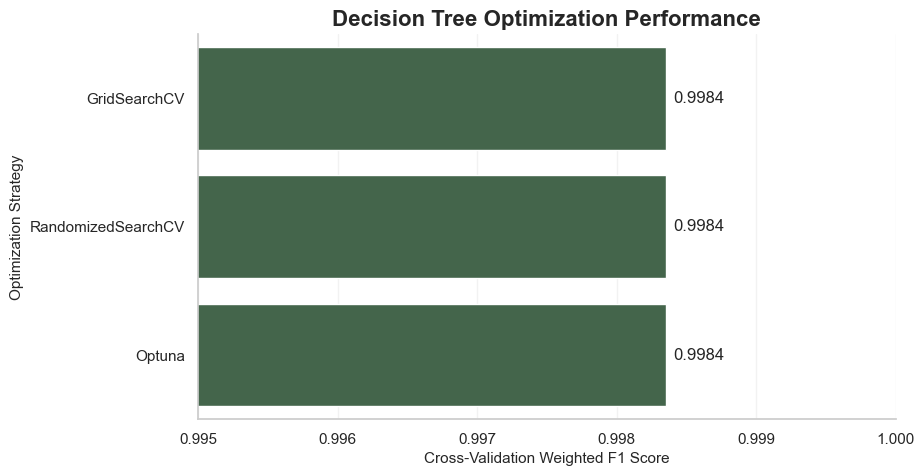

In [169]:
# Hyperparameter optimization visualization

plt.figure(
    figsize=(9,5)
)


ax = sns.barplot(
    data=optimization_results,
    x="F1 Score",
    y="Method",
    color="#3E6B48"
)


plt.title(
    "Decision Tree Optimization Performance",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel(
    "Cross-Validation Weighted F1 Score"
)


plt.ylabel(
    "Optimization Strategy"
)


plt.xlim(
    0.995,
    1.000
)


# Add score labels

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=5
    )


plt.grid(
    axis="x",
    alpha=0.25
)


sns.despine()


plt.show()

**Interpretation**

The three optimization strategies achieved similar F1-Score results, indicating model stability.

GridSearchCV was selected as the final configuration because it maintained high performance while preserving a simpler and more interpretable model structure.

# 7. Final Model Evaluation

The optimized Decision Tree model was evaluated on the test dataset to measure its performance on unseen data.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Classification Report
- Confusion Matrix
- ROC Curve

These metrics provide a complete understanding of the model performance and its impact on environmental risk prediction.

## Select Final Model

In [170]:
# Select final optimized model

final_model = (
    grid_search
    .best_estimator_
)

In [171]:
# Generate predictions

final_predictions = (
    final_model
    .predict(
        X_test
    )
)


# Generate probabilities

final_probabilities = (
    final_model
    .predict_proba(
        X_test
    )
)

## Final Metrics

In [172]:
# Final evaluation metrics

final_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],

        "Score": [
            
            accuracy_score(
                y_test,
                final_predictions
            ),

            precision_score(
                y_test,
                final_predictions,
                average="weighted"
            ),

            recall_score(
                y_test,
                final_predictions,
                average="weighted"
            ),

            f1_score(
                y_test,
                final_predictions,
                average="weighted"
            ),

            roc_auc_score(
                y_test,
                final_probabilities,
                multi_class="ovr",
                average="weighted"
            )
        ]
    }
)


final_metrics

,Metric,Score
0,Accuracy,0.996667
1,Precision,0.996693
2,Recall,0.996667
3,F1 Score,0.996635
4,ROC-AUC,0.997143


**Interpretation**

The optimized Decision Tree model achieved strong predictive performance across all evaluation metrics.

The high F1-Score indicates that the model maintains a strong balance between Precision and Recall.

For environmental compliance management, Recall is especially important because failing to identify high-risk projects could result in insufficient monitoring and possible regulatory impacts.

The high ROC-AUC value confirms that the model effectively separates the different environmental risk categories.

## Classification Report

In [173]:
# Classification report with English labels

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "High Risk",
            "Low Risk",
            "Medium Risk"
        ]
    )
)

              precision    recall  f1-score   support

   High Risk       1.00      0.95      0.98        44
    Low Risk       1.00      1.00      1.00       306
 Medium Risk       0.99      1.00      1.00       250

    accuracy                           1.00       600
   macro avg       1.00      0.98      0.99       600
weighted avg       1.00      1.00      1.00       600



**Interpretation**

The model achieved excellent results across all environmental risk categories.

The High Risk category obtained a recall of 0.95, meaning that most critical projects were correctly identified.

This is particularly relevant because High Risk projects require priority monitoring and preventive management actions.

## Confusion Matrix

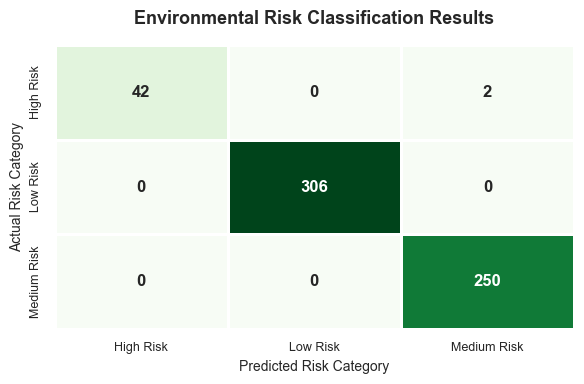

In [179]:
# Confusion matrix visualization

english_labels = ["High Risk", "Low Risk", "Medium Risk"]

cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=english_labels,
    yticklabels=english_labels,
    cbar=False,
    linewidths=2,
    linecolor="white",
    annot_kws={
        "size": 12,
        "weight": "bold"
    }
)

plt.title(
    "Environmental Risk Classification Results",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Predicted Risk Category",
    fontsize=10
)

plt.ylabel(
    "Actual Risk Category",
    fontsize=10
)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()



plt.show()

**Interpretation**

The confusion matrix shows that the optimized model correctly classified most environmental risk cases.

Only two High Risk projects were classified as Medium Risk, representing the main business concern because underestimated risks could reduce monitoring priority.

Overall, the model provides reliable support for environmental compliance prioritization and preventive decision-making.

## ROC Curve Analysis

In [ ]:
# Binarize multiclass target

classes = final_model.classes_


y_test_binary = label_binarize(
    y_test,
    classes=classes
)

In [ ]:
# Define English class labels

class_labels = {
    "Alto": "High Risk",
    "Bajo": "Low Risk",
    "Medio": "Medium Risk"
}


english_labels = [
    class_labels[label]
    for label in final_model.classes_
]


english_labels

['High Risk', 'Low Risk', 'Medium Risk']

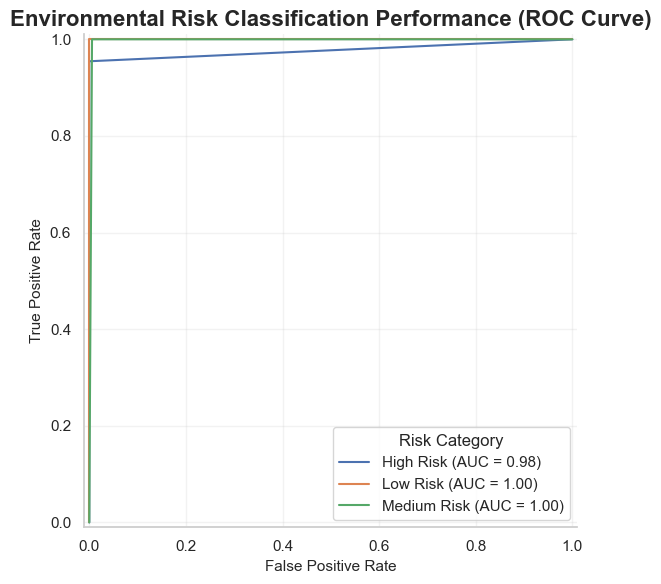

In [ ]:
# ROC Curve visualization

fig, ax = plt.subplots(
    figsize=(8,6)
)


for i, class_name in enumerate(classes):

    RocCurveDisplay.from_predictions(
        y_test_binary[:, i],
        final_probabilities[:, i],
        name=class_labels[class_name],
        ax=ax
    )


ax.set_title(
    "Environmental Risk Classification Performance (ROC Curve)",
    fontsize=16,
    fontweight="bold"
)


ax.set_xlabel(
    "False Positive Rate"
)


ax.set_ylabel(
    "True Positive Rate"
)


ax.grid(
    alpha=0.25
)


ax.legend(
    title="Risk Category",
    loc="lower right"
)


sns.despine()


plt.tight_layout()


plt.show()

**Interpretation**

The ROC Curve shows a strong ability to distinguish between environmental compliance risk categories.

The model achieved excellent discrimination performance, with AUC values of 0.98 for High Risk and 1.00 for Low and Medium Risk categories.

From an environmental management perspective, this indicates that the model can effectively support early identification of projects requiring preventive monitoring actions.

# 8. Model Interpretation

After evaluating the optimized model performance, feature importance analysis was performed to understand which variables contributed the most to environmental risk classification.

Model interpretability is essential in environmental management because predictions should support transparent decision-making.

## Feature Importance

In [ ]:
# Extract feature importance values

feature_importance = (
    final_model
    .named_steps["classifier"]
    .feature_importances_
)

In [ ]:
# Get transformed feature names

feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [ ]:
# Create feature importance dataframe

importance_df = (
    pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": feature_importance
        }
    )
    .sort_values(
        by="Importance",
        ascending=False
    )
)


importance_df.head(
    10
)

,Feature,Importance
2120,categorical__criticality_Alta,0.640435
5,numeric__compliance_percentage,0.134951
2125,categorical__progress_status_Pendiente,0.111510
1,numeric__remaining_days,0.098782
2,numeric__non_compliance_history,0.012837
1712,categorical__rca_number_RCA-8236,0.001484
3,numeric__document_count,0.000000
4,numeric__associated_budget_usd,0.000000
6,categorical__company_AES Andes,0.000000
7,categorical__company_CGE,0.000000


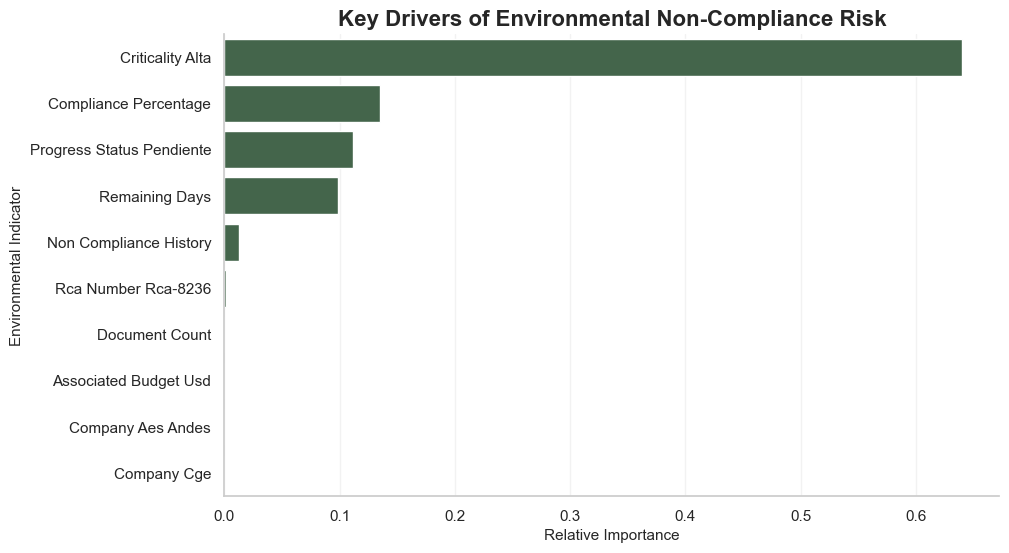

In [ ]:
# Prepare feature names for visualization

top_features = (
    importance_df
    .head(10)
    .copy()
)


top_features["Feature"] = (
    top_features["Feature"]
    .str.replace(
        "numeric__",
        "",
        regex=False
    )
    .str.replace(
        "categorical__",
        "",
        regex=False
    )
    .str.replace(
        "_",
        " "
    )
    .str.title()
)


# Plot feature importance

plt.figure(
    figsize=(10,6)
)


sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    color="#3E6B48"
)


plt.title(
    "Key Drivers of Environmental Non-Compliance Risk",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel(
    "Relative Importance"
)


plt.ylabel(
    "Environmental Indicator"
)


sns.despine()


plt.grid(
    axis="x",
    alpha=0.25
)


plt.show()

**Interpretation**

The feature importance analysis indicates that environmental risk classification is mainly influenced by criticality level, compliance percentage, project progress status, remaining compliance days, and previous non-compliance history.

These indicators provide actionable information that can help environmental teams focus monitoring efforts on higher-risk projects.

# 9. Model Deployment

The final optimized model was saved to allow future predictions without retraining.

The saved object includes:

- Data preprocessing steps.
- Feature transformations.
- Optimized Decision Tree classifier.

Saving the complete pipeline ensures reproducibility in production environments.

## Save Final Model

In [ ]:
# Save final model pipeline

joblib.dump(
    final_model,
    "environmental_risk_model.joblib"
)

['environmental_risk_model.joblib']

In [ ]:
# Load saved model

loaded_model = joblib.load(
    "environmental_risk_model.joblib"
)


loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Alto','Bajo','Medio']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['company','project_type','region',...,'criticality', 'compliance_percentage','progress_status']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default o

#  Executive Summary

## Project Outcome

A supervised Machine Learning classification model was developed to predict environmental non-compliance risk levels.

The project implemented a complete Machine Learning workflow including data preprocessing, transformation pipelines, model benchmarking, hyperparameter optimization, performance evaluation, and model interpretation.

The final solution provides a data-driven approach to support environmental teams in identifying projects that require higher monitoring priority and preventive management actions.


## Final Model Performance

After evaluating multiple classification algorithms, the optimized Decision Tree Classifier was selected as the final model because it achieved strong predictive performance while maintaining interpretability.

The final model achieved:

- Accuracy: 99.67%
- Precision: 99.67%
- Recall: 99.67%
- F1-Score: 99.66%
- ROC-AUC: 99.71%

The model demonstrated a high ability to classify environmental compliance risk levels and distinguish between Low Risk, Medium Risk, and High Risk projects.

The confusion matrix analysis showed that only two High Risk projects were classified as Medium Risk, representing the main operational risk because underestimated cases could receive lower monitoring priority.


## Key Environmental Insights

The feature importance analysis identified the main variables influencing environmental non-compliance risk prediction:

- Criticality level.
- Compliance percentage.
- Project progress status.
- Remaining compliance days.
- Previous non-compliance history.

These factors are consistent with environmental compliance management processes and represent indicators that organizations can monitor to detect potential risks earlier.


## Business Value

The developed model can support environmental management processes by enabling:

- Early identification of projects with higher non-compliance risk.
- Prioritization of inspections and monitoring activities.
- More efficient allocation of environmental resources.
- Preventive decision-making based on historical compliance patterns.

By combining predictive performance with interpretability, the model can act as a decision-support tool rather than only an automated classifier.


## Future Improvements

Future versions of this project could improve model robustness by incorporating:

- Additional historical compliance records.
- Real environmental inspection and audit results.
- External environmental indicators.
- Continuous monitoring of model performance over time.

# AI Usage Disclosure

Artificial Intelligence tools were used solely for English writing support, grammatical editing, and documentation formatting.

All analytical decisions, data cleaning strategies, interpretations, business insights, and final conclusions were independently developed, reviewed, and validated by the author.